To run code:

```
baseline: uv run --python .venv310/bin/python python run_train_validate.py --mode baseline --max-frames 2000000
no trust region: uv run --python .venv310/bin/python python run_train_validate.py --mode no_trust_region --max-frames 2000000
no soft watkins: uv run --python .venv310/bin/python python run_train_validate.py --mode no_soft_watkins --max-frames 2000000
```

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams._get = mpl.rcParams.get

RESULTS_ROOT = Path("results")
RUN_DIRS = {
    "baseline": RESULTS_ROOT / "baseline_10m",
    "no_trust_region": RESULTS_ROOT / "no_trust_region_10m",
    "no_soft_watkins": RESULTS_ROOT / "no_soft_watkins_10m",
}

for name, path in RUN_DIRS.items():
    print(f"{name}: {'OK' if path.exists() else 'MISSING'} -> {path}")

baseline: OK -> results/baseline_10m
no_trust_region: OK -> results/no_trust_region_10m
no_soft_watkins: OK -> results/no_soft_watkins_10m


In [2]:
def load_run_artifacts(run_name: str, run_path: Path):
    train_csv = run_path / "training_rows.csv"
    eval_csv = run_path / "validation_episodes.csv"
    eval_summary_json = run_path / "validation_summary.json"

    train_df = pd.read_csv(train_csv)

    eval_df = pd.DataFrame()
    if eval_csv.exists():
        eval_df = pd.read_csv(eval_csv)

    return {
        "name": run_name,
        "path": run_path,
        "train": train_df,
        "eval": eval_df,
        "has_eval": eval_csv.exists() and not eval_df.empty,
        "eval_summary_path": eval_summary_json,
    }


runs = [load_run_artifacts(name, path) for name, path in RUN_DIRS.items()]

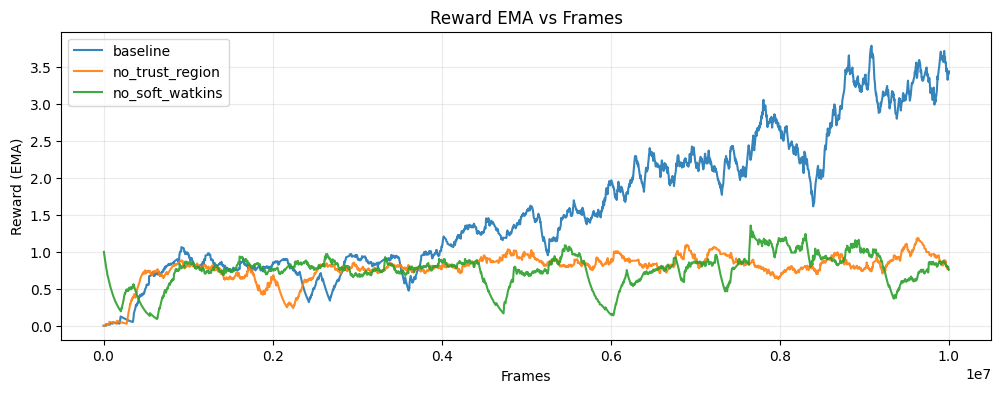

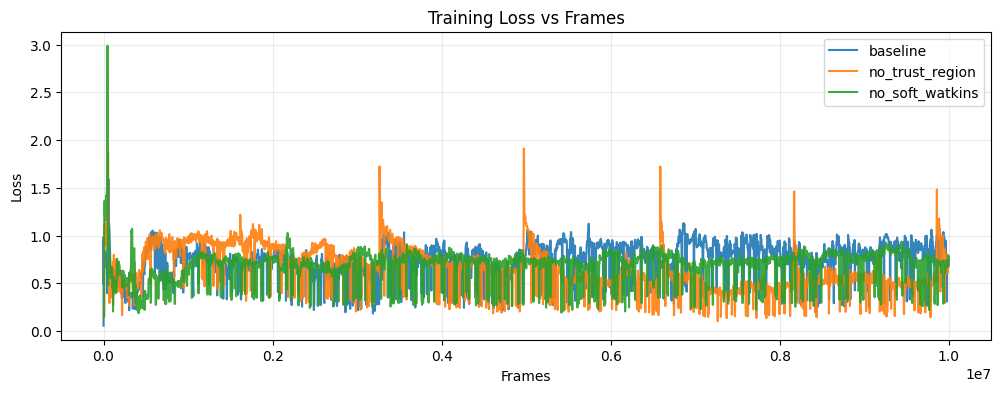

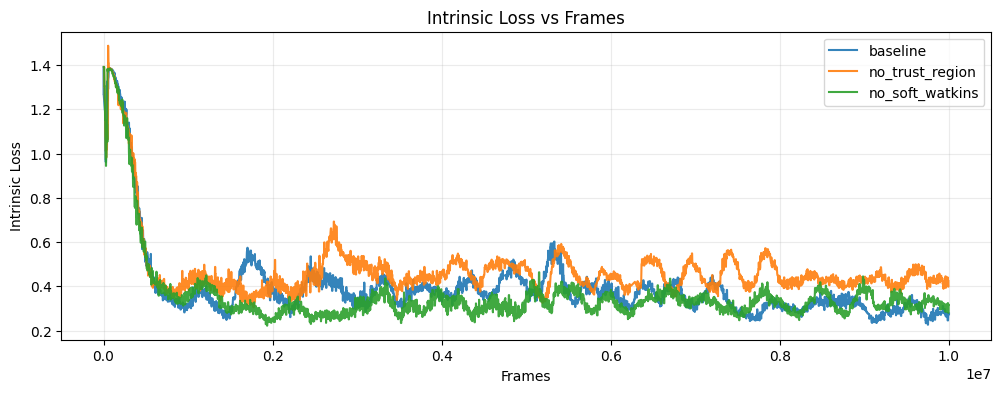

In [3]:
plt.figure(figsize=(12, 4))
ema_alpha = 0.02
for run in runs:
    df = run["train"].copy()
    reward_ema = df["reward"].ewm(alpha=ema_alpha, adjust=False).mean()
    plt.plot(df["total_frames"], reward_ema, label=run["name"], alpha=0.9)
plt.title("Reward EMA vs Frames")
plt.xlabel("Frames")
plt.ylabel("Reward (EMA)")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

plt.figure(figsize=(12, 4))
for run in runs:
    df = run["train"]
    plt.plot(df["total_frames"], df["loss"], label=run["name"], alpha=0.9)
plt.title("Training Loss vs Frames")
plt.xlabel("Frames")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

plt.figure(figsize=(12, 4))
for run in runs:
    df = run["train"]
    plt.plot(df["total_frames"], df["intrinsic_loss"], label=run["name"], alpha=0.9)
plt.title("Intrinsic Loss vs Frames")
plt.xlabel("Frames")
plt.ylabel("Intrinsic Loss")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

Evaluation scores:


,run,episodes,mean_return,min_return,max_return
0,baseline,100,4.79,0.0,11.0
1,no_soft_watkins,100,0.86,0.0,1.0
2,no_trust_region,100,1.33,0.0,3.0


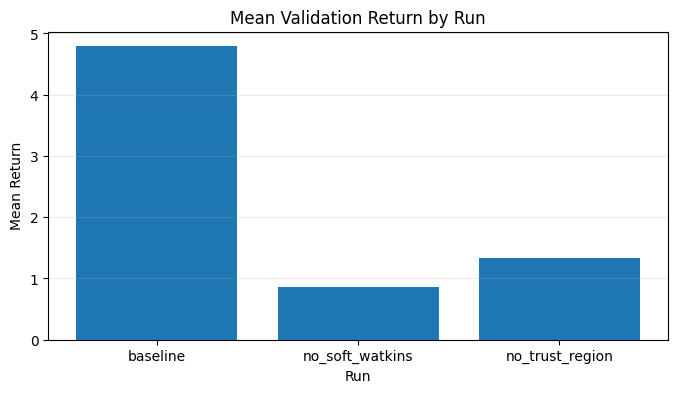

In [4]:
rows = []
for run in runs:
    eval_df = run["eval"]
    if eval_df.empty:
        rows.append({
            "run": run["name"],
            "episodes": 0,
            "mean_return": None,
            "min_return": None,
            "max_return": None,
        })
    else:
        rows.append({
            "run": run["name"],
            "episodes": int(len(eval_df)),
            "mean_return": float(eval_df["return"].mean()),
            "min_return": float(eval_df["return"].min()),
            "max_return": float(eval_df["return"].max()),
        })

scores_df = pd.DataFrame(rows).sort_values("run").reset_index(drop=True)
print("Evaluation scores:")
display(scores_df)

plot_df = scores_df.dropna(subset=["mean_return"])
if not plot_df.empty:
    plt.figure(figsize=(8, 4))
    plt.bar(plot_df["run"], plot_df["mean_return"])
    plt.title("Mean Validation Return by Run")
    plt.xlabel("Run")
    plt.ylabel("Mean Return")
    plt.grid(axis="y", alpha=0.25)
    plt.show()